**Section 1: Introduction**

**# Exploratory Data Analysis (EDA)**

**## Objective**

The goal of this exploratory analysis is to identify demographic, clinical, and lifestyle factors associated with stroke occurrence.

**This analysis explores:**

- Stroke prevalence
- Demographic risk patterns
- Clinical risk factors
- Lifestyle-related factors
- Relationships between numerical variables

Insights generated from this analysis will support feature engineering and predictive modelling in subsequent phases of the project.

In [2]:
## Section 2: Load Cleaned Dataset
# Import libraries required for data analysis and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Improve chart appearance
plt.style.use("default")

# Load cleaned dataset produced in Issue #3

df = pd.read_csv("/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_cleaned.csv")

# View first few rows

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
## Section 3: Dataset Overview
# View dataset dimensions
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_cleaned.csv")

df.shape

(5110, 11)

In [4]:
# Review column names
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_cleaned.csv")


df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [5]:
# Confirm data types
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_cleaned.csv")


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


**Section 4: Overall Stroke Prevalence** *italicized text*

**EDA 1: Overall Stroke Prevalence**

**Business Question**

How many patients experienced stroke compared to those who did not?

**Why This Analysis Matters**

Before performing advanced analysis, we need to understand the distribution of the target variable (stroke).

This helps identify whether the dataset is balanced or imbalanced, which is important for machine learning modelling.

In [6]:
# Count Stroke Cases
# Count how many patients belong to each stroke category.
#
# stroke = 0 means No Stroke
# stroke = 1 means Stroke
#
# value_counts() counts the number of occurrences of each value.
#
# We do this to understand how common stroke cases are in the dataset.

stroke_counts = df["stroke"].value_counts()

# Display the results

stroke_counts

,count
stroke,
0,4861
1,249


**Interpretation**

4,861 patients did not have a stroke.

249 patients had a stroke.

In [7]:
## Calculate Percentages
# Convert counts into percentages.
#
# normalize=True converts counts into proportions.
#
# Multiplying by 100 converts proportions into percentages.
#
# Percentages make interpretation easier than raw counts.

stroke_percentages = df["stroke"].value_counts(normalize=True) * 100

stroke_percentages

,proportion
stroke,
0,95.127202
1,4.872798


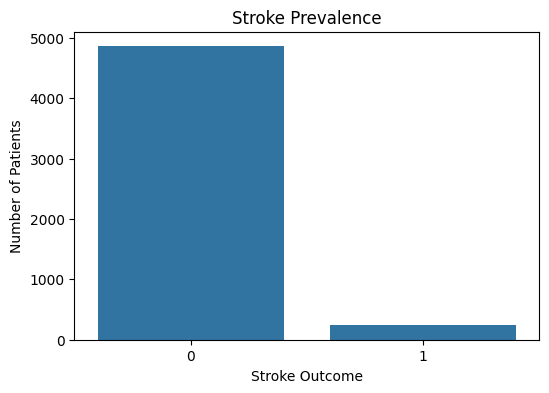

In [8]:
# Visualize Class Distribution
# Create a chart area.
#
# figsize controls the size of the figure.

plt.figure(figsize=(6,4))

# Create a count plot.
#
# countplot automatically counts observations in each category.

sns.countplot(
    data=df,
    x="stroke"
)

# Add chart title.

plt.title("Stroke Prevalence")

# Label x-axis.

plt.xlabel("Stroke Outcome")

# Label y-axis.

plt.ylabel("Number of Patients")

# Display chart.

plt.show()

**### Interpretation**

The dataset is highly imbalanced.

Out of 5,110 patients:

- 4,861 patients (95.13%) did not experience stroke.
- 249 patients (4.87%) experienced stroke.

This means stroke cases are relatively rare within the dataset.

**Why is this important?**

Machine learning models tend to favor the majority class when data is highly imbalanced.

Without addressing this imbalance, a model may predict "No Stroke" for most patients and still appear accurate while failing to identify high-risk patients.

This issue will be addressed later during Feature Engineering using techniques such as SMOTE.

**## Section 5: Stroke Rate by Age Group**

**EDA 2: Stroke Rate by Age Group**


**Business Question**

Which age groups experience the highest stroke rates?

**Why This Analysis Matters**

Age is one of the most important risk factors for stroke.

Grouping patients into age categories allows us to identify which age ranges are most vulnerable.

In [9]:
## Create Age Groups
# Create age group boundaries.
#
# Continuous ages are easier to interpret when grouped into categories.

bins = [0,18,35,50,65,100]

# Create labels for each age category.

labels = [
    "0-18",
    "19-35",
    "36-50",
    "51-65",
    "66+"
]

# Assign each patient to an age group.
#
# pd.cut() places each age into the correct category.

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [10]:
## Calculate Stroke Rate
# Calculate stroke rate for each age group.
#
# stroke is binary:
# 0 = No Stroke
# 1 = Stroke
#
# The mean of a binary variable equals the proportion of positive cases.

age_stroke_rate = (
    df.groupby("age_group")["stroke"]
      .mean()
      * 100
)

age_stroke_rate

/tmp/ipykernel_4001/895425487.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["stroke"]


,stroke
age_group,
0-18,0.218341
19-35,0.101729
36-50,1.845018
51-65,6.024096
66+,16.165803


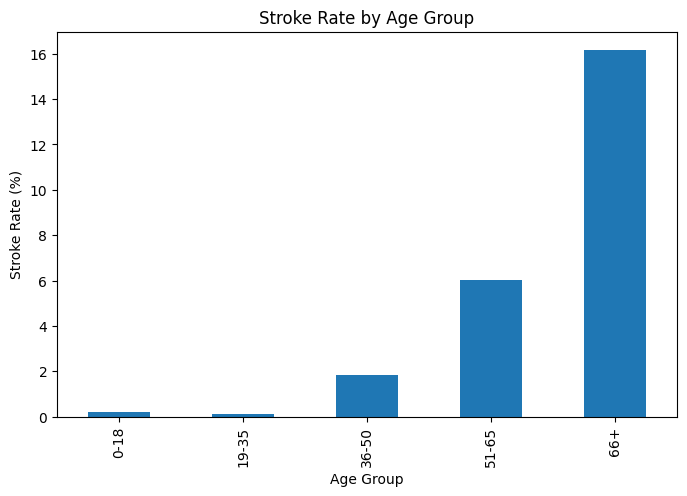

In [11]:
## Visualize
# Create chart.

plt.figure(figsize=(8,5))

# Create bar chart showing stroke rates.

age_stroke_rate.plot(kind="bar")

# Add chart title.

plt.title("Stroke Rate by Age Group")

# Label axes.

plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

**### Interpretation**


Stroke rates increase significantly with age.


Younger patients show very low stroke prevalence, while older adults show much higher rates.


This suggests age is one of the strongest predictors of stroke occurrence.

The finding is consistent with medical research showing that stroke risk increases as people age due to cumulative exposure to cardiovascular risk factors.

# **Section 6: Stroke Rate by Gender**

# **# EDA Task 3: Stroke Rate by Gender**

# **Business Question**

Does stroke occurrence differ between males and females?

# **Why This Analysis Matters**

Gender is a common demographic variable in healthcare analytics.

Understanding whether stroke prevalence differs by gender can help healthcare professionals identify vulnerable populations and design targeted prevention programs.

This analysis helps determine whether gender may be an important predictor in stroke risk modelling.

In [12]:
## Calculate Stroke Rate by Gender
# Group patients by gender.
#
# The groupby() function separates the dataset into groups
# based on the values found in the gender column.
#
# In this dataset:
# - Male
# - Female
# - Other
#
# We want to calculate the percentage of patients
# who experienced stroke within each gender group.

gender_stroke = (
    df.groupby("gender")["stroke"]
      .mean()
      * 100
)

# Display the stroke rate for each gender.

gender_stroke

,stroke
gender,
Female,4.709419
Male,5.106383
Other,0.000000


# **Why Are We Using Mean?**

The stroke column contains:

0 = No Stroke
1 = Stroke

# **When we calculate the mean:**

Example:

[0,0,0,1]

Mean = 0.25

This means 25% of patients experienced stroke.

Therefore the mean of a binary variable is equivalent to its rate or proportion.

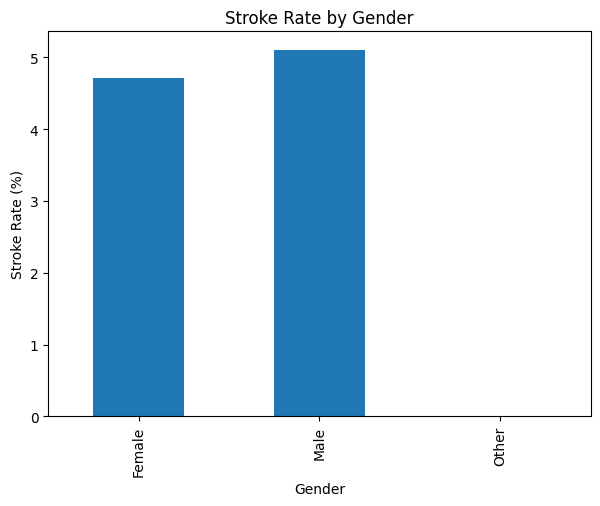

In [13]:
## Visualize Stroke Rate by Gender
# Create a larger chart for readability.

plt.figure(figsize=(7,5))

# Create a bar chart.
#
# Bar charts are useful when comparing categories.

gender_stroke.plot(kind="bar")

# Add a descriptive title.

plt.title("Stroke Rate by Gender")

# Label the x-axis.

plt.xlabel("Gender")

# Label the y-axis.

plt.ylabel("Stroke Rate (%)")

# Display the chart.

plt.show()

# **Interpretation**

Male patients show the highest stroke rate (≈5.1%), followed closely by female patients (≈4.7%).

The difference between the two groups is small, indicating that stroke occurrence is relatively similar across genders in this dataset.

The "Other" category records no stroke cases, though this result should be interpreted cautiously due to the small sample size.

# **Section 7: Stroke Rate by Marital Status**

# **EDA Task 4: Stroke Rate by Marital Status**


# **Business Question**

Does stroke prevalence differ between married and unmarried patients?


# **Why This Analysis Matters**

Marital status is often associated with age, lifestyle, stress levels, and social support systems.

This analysis helps determine whether marital status is related to stroke occurrence and whether it may be useful in predictive modelling.


In [14]:
## Calculate Stroke Rate by Marital Status
# Group patients based on marital status.
#
# Categories:
# - Yes (Ever Married)
# - No (Never Married)
#
# Calculate the percentage of patients
# who experienced stroke in each group.

married_stroke = (
    df.groupby("ever_married")["stroke"]
      .mean()
      * 100
)

# Display results.

married_stroke

,stroke
ever_married,
No,1.650541
Yes,6.561288


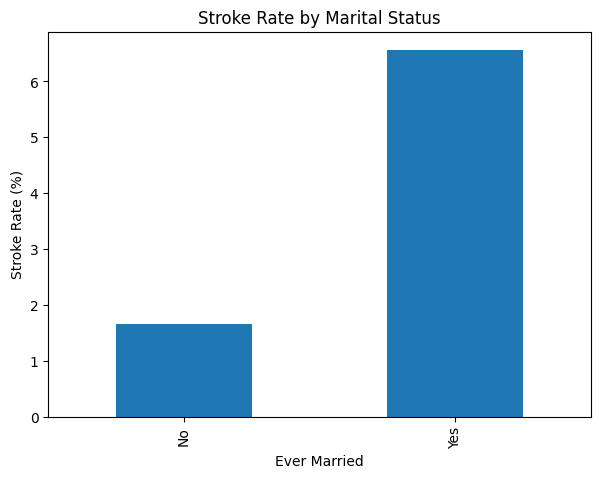

In [15]:
## Visualize Stroke Rate by Marital Status
# Create chart area.

plt.figure(figsize=(7,5))

# Plot stroke rates.

married_stroke.plot(kind="bar")

# Add chart title.

plt.title("Stroke Rate by Marital Status")

# Label x-axis.

plt.xlabel("Ever Married")

# Label y-axis.

plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Interpretation**

The chart shows that patients who have been married (Yes) have a higher stroke rate (approximately 6.6%) compared to those who have never been married (No), whose stroke rate is approximately 1.7%.

This indicates that stroke occurrence is more common among individuals who have been married in this dataset.

# **Key Insight**

Patients who have been married show a noticeably higher stroke rate than those who have not.

# **Section 8: Stroke Rate by Work Type**

# **EDA 5: Stroke Rate by Work Type**

# **Business Question**

Does stroke prevalence differ across different work categories?


# **Why This Analysis Matters**

Occupation and employment status can influence lifestyle, stress levels,
physical activity, income, healthcare access, and overall health outcomes.

Analyzing stroke rates by work type helps identify whether certain
employment groups appear to be at higher risk.

This information may support healthcare planning and targeted prevention efforts.

In [16]:
## alculate Stroke Rate by Work Type
# Group patients according to their work type.
#
# The work_type column contains:
# - Private
# - Self-employed
# - Govt_job
# - children
# - Never_worked
#
# We calculate the average of the stroke column because:
#
# stroke = 0 → No Stroke
# stroke = 1 → Stroke
#
# The mean therefore represents the proportion of patients
# who experienced stroke in each work category.
#
# Multiplying by 100 converts the proportions into percentages.

work_stroke_rate = (
    df.groupby("work_type")["stroke"]
      .mean()
      * 100
)

# Display stroke rates for each work category.

work_stroke_rate

,stroke
work_type,
Govt_job,5.022831
Never_worked,0.000000
Private,5.094017
Self-employed,7.936508
children,0.291121


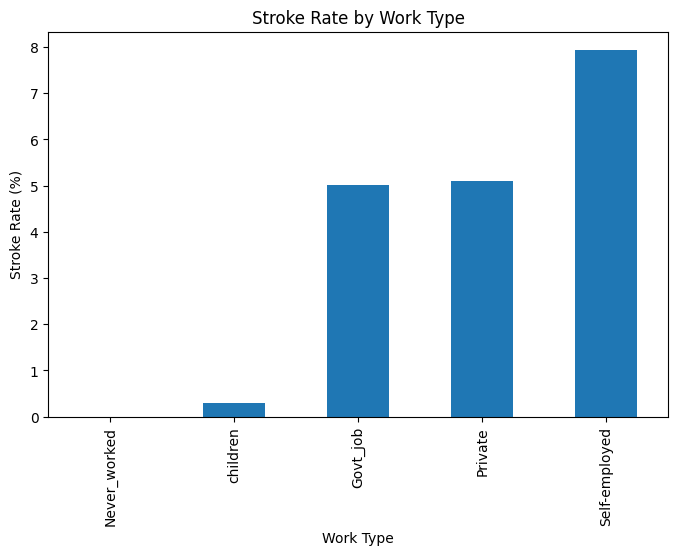

In [17]:
## Visualize Stroke Rate by Work Type
# Create chart area.
#
# figsize controls chart size.

plt.figure(figsize=(8,5))

# Create bar chart.
#
# Sorting values makes comparison easier.

work_stroke_rate.sort_values().plot(kind="bar")

# Add chart title.

plt.title("Stroke Rate by Work Type")

# Label x-axis.

plt.xlabel("Work Type")

# Label y-axis.

plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Intrepretation**


The chart shows the percentage of patients who experienced a stroke within each work type category.


Patients who were self-employed had the highest stroke rate (approximately 8%), indicating a greater proportion of stroke cases compared to other employment groups. Patients working in private organizations and government jobs had similar stroke rates of about 5%.



The children category recorded a very low stroke rate (less than 1%). The Never_worked category showed no recorded stroke cases in this dataset.



These findings indicate that stroke occurrence varies across different work type categories in the dataset.

# **Section 9: Stroke Rate by Residence Type**

# **EDA 6: Stroke Rate by Residence Type**

# **Business Question**

Does stroke prevalence differ between urban and rural residents?

# **Why This Analysis Matters**

People living in urban and rural environments may experience different
lifestyles, healthcare access, environmental exposures, and socioeconomic
conditions.


Understanding these differences helps identify whether residence type is
associated with stroke occurrence.

In [18]:
## Calculate Stroke Rate by Residence Type
# Group patients according to residence type.
#
# Residence_type contains:
# - Urban
# - Rural
#
# We calculate the average of the stroke column because:
#
# stroke = 0 → No Stroke
# stroke = 1 → Stroke
#
# The mean therefore represents the stroke rate for each group.

residence_stroke_rate = (
    df.groupby("Residence_type")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

residence_stroke_rate

,stroke
Residence_type,
Rural,4.534606
Urban,5.200308


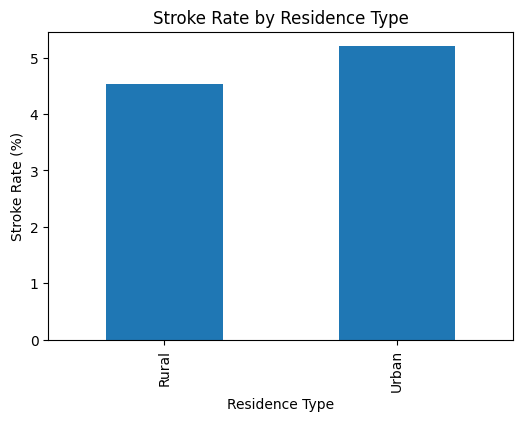

In [19]:
## Visualize Stroke Rate by Residence Type
# Create chart area.

plt.figure(figsize=(6,4))

# Create bar chart.

residence_stroke_rate.plot(kind="bar")

# Add title.

plt.title("Stroke Rate by Residence Type")

# Label axes.

plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Interpretation**

The chart compares the percentage of patients who experienced a stroke between Rural and Urban residence categories.



Patients living in Urban areas had a slightly higher stroke rate (approximately 5.2%) compared to those living in Rural areas (approximately 4.5%).



The difference in stroke rates between the two residence types is relatively small, but it indicates that stroke occurrence varies slightly across residential settings in this dataset.

# **Section 10: Hypertension vs Stroke**

# **EDA 7: Hypertension vs Stroke**

# Business Question

Do patients with hypertension experience higher stroke rates than patients without hypertension?


# **Why This Analysis Matters**

Hypertension (high blood pressure) is one of the most important and well-known
risk factors for stroke.

Long-term elevated blood pressure can damage blood vessels and increase the
likelihood of both ischemic and hemorrhagic stroke.

This analysis helps determine the strength of the relationship between
hypertension and stroke occurrence within the dataset.

In [20]:
## Calculate Stroke Rate by Hypertension Status
# Group patients according to hypertension status.
#
# hypertension = 0 → No Hypertension
# hypertension = 1 → Hypertension
#
# Calculate the mean stroke value within each group.
#
# Since:
# stroke = 0 → No Stroke
# stroke = 1 → Stroke
#
# The mean represents the stroke rate.
#
# Multiplying by 100 converts the proportion into a percentage.

hypertension_stroke_rate = (
    df.groupby("hypertension")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

hypertension_stroke_rate

,stroke
hypertension,
0,3.967910
1,13.253012


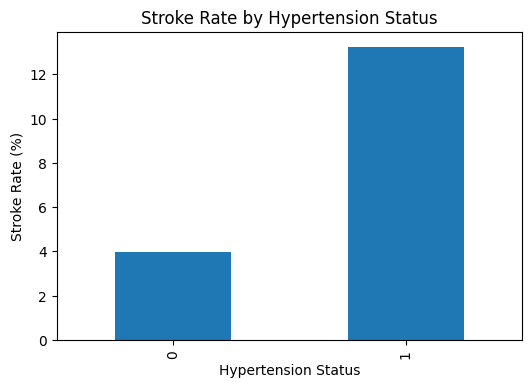

In [23]:
## Visualize Stroke Rate by Hypertension Status
# Create chart area.

plt.figure(figsize=(6,4))

# Create bar chart.

hypertension_stroke_rate.plot(kind="bar")

# Add title.

plt.title("Stroke Rate by Hypertension Status")

# Label axes.

plt.xlabel("Hypertension Status")
plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Interpretation**

The chart compares the percentage of patients who experienced a stroke between individuals without hypertension (0) and those with hypertension (1).


Patients with hypertension had a substantially higher stroke rate (approximately 13%) compared to patients without hypertension (approximately 4%).


This indicates a strong association between hypertension and stroke occurrence in the dataset. The stroke rate among individuals with hypertension is more than three times higher than the rate observed among those without hypertension.


The noticeable difference between the two groups suggests that hypertension is an important factor associated with stroke prevalence within this population.

# **Section 11: Heart Disease vs Stroke**

# **EDA 8: Heart Disease vs Stroke**


# **Business Question**


Do patients with heart disease experience higher stroke rates than patients without heart disease?


# **Why This Analysis Matters**

Heart disease and stroke are both cardiovascular conditions that often share
common risk factors such as hypertension, diabetes, obesity, and smoking.


Patients with heart disease may have impaired blood circulation, increasing
their risk of stroke.


This analysis helps determine whether heart disease is associated with a higher
rate of stroke occurrence within the dataset.

In [24]:
## Calculate Stroke Rate by Heart Disease Status
# Group patients according to heart disease status.
#
# heart_disease = 0 → No Heart Disease
# heart_disease = 1 → Heart Disease
#
# We calculate the average stroke value within each group.
#
# Since:
# stroke = 0 → No Stroke
# stroke = 1 → Stroke
#
# The mean of the stroke column represents the stroke rate.
#
# Multiplying by 100 converts the proportion into a percentage.

heart_stroke_rate = (
    df.groupby("heart_disease")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

heart_stroke_rate

,stroke
heart_disease,
0,4.178734
1,17.028986


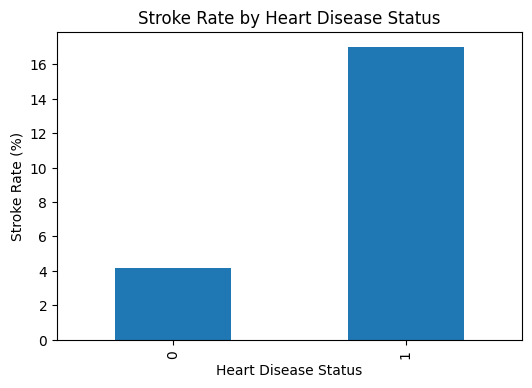

In [25]:
## Visualize Stroke Rate by Heart Disease Status
# Create chart area.

plt.figure(figsize=(6,4))

# Create bar chart comparing stroke rates.

heart_stroke_rate.plot(kind="bar")

# Add title.

plt.title("Stroke Rate by Heart Disease Status")

# Label axes.

plt.xlabel("Heart Disease Status")
plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Interpretation**

The chart compares the percentage of patients who experienced a stroke between individuals without heart disease (0) and those with heart disease (1).


Patients with heart disease had a considerably higher stroke rate (approximately 17%) compared to patients without heart disease (approximately 4%).


This indicates a strong association between heart disease and stroke occurrence in the dataset. The stroke rate among individuals with heart disease is more than four times higher than the rate observed among those without heart disease.


The substantial difference between the two groups suggests that heart disease is an important factor associated with stroke prevalence within this population.

# **Section 12: Glucose Distribution**

# **EDA 9: Glucose Level Distribution**


# **Business Question**

Do stroke patients tend to have higher average glucose levels than non-stroke patients?


# **Why This Analysis Matters**

Elevated blood glucose levels are associated with diabetes and other metabolic
conditions that increase cardiovascular risk.

Comparing glucose distributions helps determine whether stroke patients exhibit
higher glucose levels than patients without stroke.

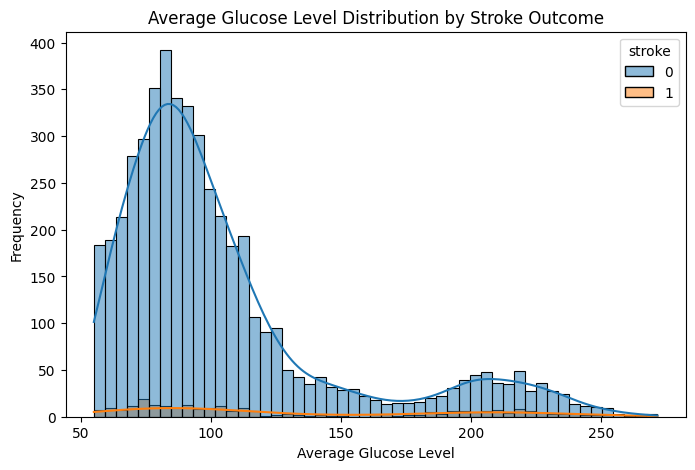

In [26]:
## Visualize Glucose Distribution
# Create chart area.
#
# We use a histogram because it shows how values are distributed.
#
# hue="stroke" separates stroke and non-stroke patients.
#
# kde=True adds a smooth density curve that helps visualize patterns.

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="avg_glucose_level",
    hue="stroke",
    kde=True
)

# Add chart title.

plt.title("Average Glucose Level Distribution by Stroke Outcome")

# Label axes.

plt.xlabel("Average Glucose Level")
plt.ylabel("Frequency")

# Display chart.

plt.show()

# **Interpretation**

The histogram compares the distribution of average glucose levels between patients who did not experience a stroke (0) and those who experienced a stroke (1).


The no-stroke group shows a wider concentration of patients with glucose levels between approximately 75 and 100 mg/dL, with the distribution extending into higher glucose ranges. The distribution appears slightly right-skewed, indicating that some individuals have considerably higher glucose levels than the majority of the population.


The stroke group is represented by fewer observations, but stroke cases are present across a broad range of glucose levels, including higher glucose values.


Overall, the distribution suggests that elevated glucose levels may be associated with stroke occurrence, as stroke cases appear more frequently among individuals with higher average glucose levels.

# **Section 13: BMI Distribution**

# **EDA 10: BMI Distribution**

# **Business Question**

Do stroke patients have different BMI patterns compared to non-stroke patients?

# **Why This Analysis Matters**

Body Mass Index (BMI) is commonly used to assess body weight relative to height.

Both obesity and extremely low BMI can be associated with adverse health
outcomes.

This analysis helps determine whether BMI differs between stroke and non-stroke
patients.

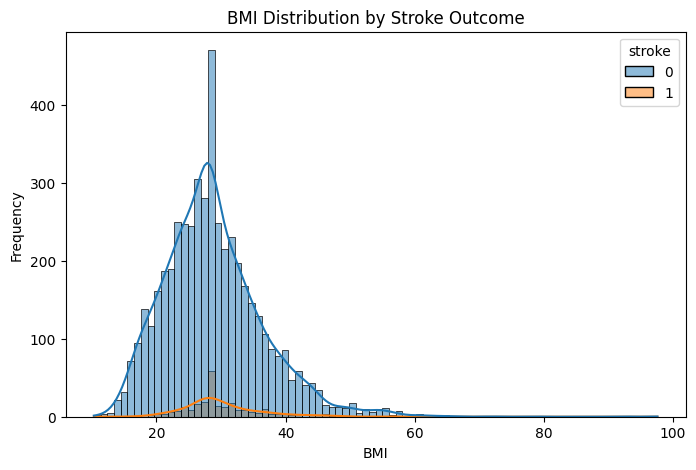

In [27]:
## Visualize BMI Distribution
# Create chart area.
#
# We use a histogram to compare BMI distributions.
#
# hue="stroke" separates stroke and non-stroke groups.
#
# kde=True adds a density curve for easier comparison.

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="bmi",
    hue="stroke",
    kde=True
)

# Add chart title.

plt.title("BMI Distribution by Stroke Outcome")

# Label axes.

plt.xlabel("BMI")
plt.ylabel("Frequency")

# Display chart.

plt.show()

# **Interpretation**

The histogram compares the distribution of Body Mass Index (BMI) between patients who did not experience a stroke (0) and those who experienced a stroke (1).

The no-stroke group shows a concentration of BMI values around 28–29, with most patients falling within the overweight range. The distribution is slightly right-skewed, indicating that some individuals have higher BMI values than the majority of the population.

The stroke group appears to have a slightly higher concentration of BMI values around 30–32, suggesting that stroke cases tend to occur more frequently among individuals with higher BMI levels. The distribution is also more spread out, indicating that stroke cases are observed across a wide range of BMI values.

There is considerable overlap between the BMI distributions of the stroke and no-stroke groups, indicating that stroke occurrence is not limited to a specific BMI category.

Overall, the distribution suggests that higher BMI may be associated with stroke occurrence, although stroke cases are present across a broad range of BMI values.

# **Section 14: Smoking Status Analysis**

# **EDA 11: Smoking Status Breakdown**


# **Business Question**


How does stroke prevalence differ across smoking categories?


# **Why This Analysis Matters**

Smoking damages blood vessels and is a well-established risk factor for stroke.

Understanding stroke prevalence across smoking categories can provide insights
into the relationship between tobacco exposure and stroke occurrence.

In [28]:
## Calculate Stroke Rate by Smoking Status
# Group patients according to smoking status.
#
# Categories include:
# - never smoked
# - formerly smoked
# - smokes
# - Unknown
#
# We calculate the average stroke value within each group.
#
# The mean represents the stroke rate.

smoking_stroke_rate = (
    df.groupby("smoking_status")["stroke"]
      .mean()
      * 100
)

# Display stroke rates.

smoking_stroke_rate

,stroke
smoking_status,
Unknown,3.044041
formerly smoked,7.909605
never smoked,4.756871
smokes,5.323194


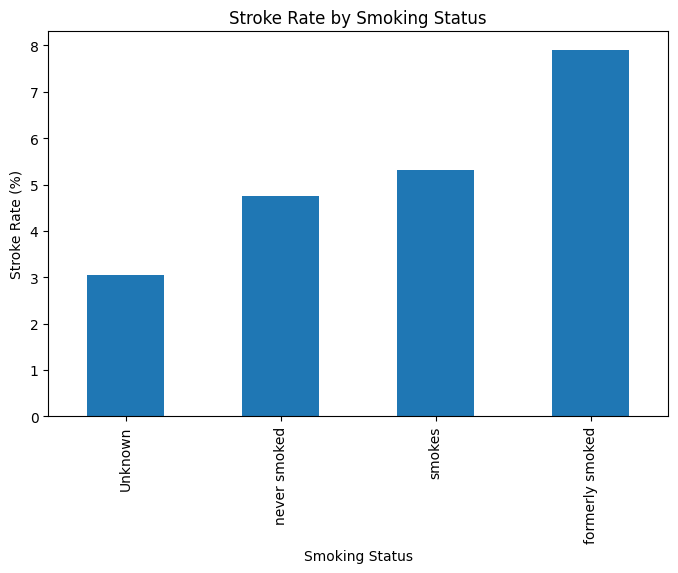

In [29]:
## Visualize Stroke Rate by Smoking Status
# Create chart area.

plt.figure(figsize=(8,5))

# Sort values for easier comparison.

smoking_stroke_rate.sort_values().plot(kind="bar")

# Add chart title.

plt.title("Stroke Rate by Smoking Status")

# Label axes.

plt.xlabel("Smoking Status")
plt.ylabel("Stroke Rate (%)")

# Display chart.

plt.show()

# **Interpretation**

The chart compares the percentage of patients who experienced a stroke across different smoking status categories.

Patients who formerly smoked had the highest stroke rate (approximately 7.9%), followed by current smokers (approximately 5.3%) and individuals who never smoked (approximately 4.8%). The Unknown category recorded the lowest stroke rate at approximately 3.1%.

The results indicate that stroke occurrence varies across smoking status groups, with higher stroke rates observed among individuals with a history of smoking. In particular, former smokers show the greatest proportion of stroke cases in the dataset.

Overall, the findings suggest an association between smoking status and stroke occurrence, with stroke rates generally being higher among individuals who currently smoke or have smoked in the past compared to those who have never smoked.

# **Section 15: Correlation Heatmap**

# **EDA 12: Correlation Heatmap**

# **Business Question**

Which numerical variables show the strongest relationships with stroke occurrence?


# **Why This Analysis Matters**

Correlation analysis helps identify variables that move together.

Understanding these relationships provides insight into which features may be
important predictors during machine learning modelling.

In [30]:
## Select Numerical Variables
# Select only numerical columns.
#
# Correlation analysis can only be performed on numerical variables.

numeric_df = df.select_dtypes(include=np.number)

# Display selected columns.

numeric_df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.6,1
1,61.0,0,0,202.21,28.1,1
2,80.0,0,1,105.92,32.5,1
3,49.0,0,0,171.23,34.4,1
4,79.0,1,0,174.12,24.0,1


In [31]:
## Calculate Correlation Matrix
# Calculate pairwise correlations.
#
# Correlation values range from:
#
# -1 = Strong Negative Relationship
#  0 = No Relationship
# +1 = Strong Positive Relationship

correlation_matrix = numeric_df.corr()

# Display correlation matrix.

correlation_matrix

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.324296,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.158293,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.036916,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.166876,0.131945
bmi,0.324296,0.158293,0.036916,0.166876,1.000000,0.036110
stroke,0.245257,0.127904,0.134914,0.131945,0.036110,1.000000


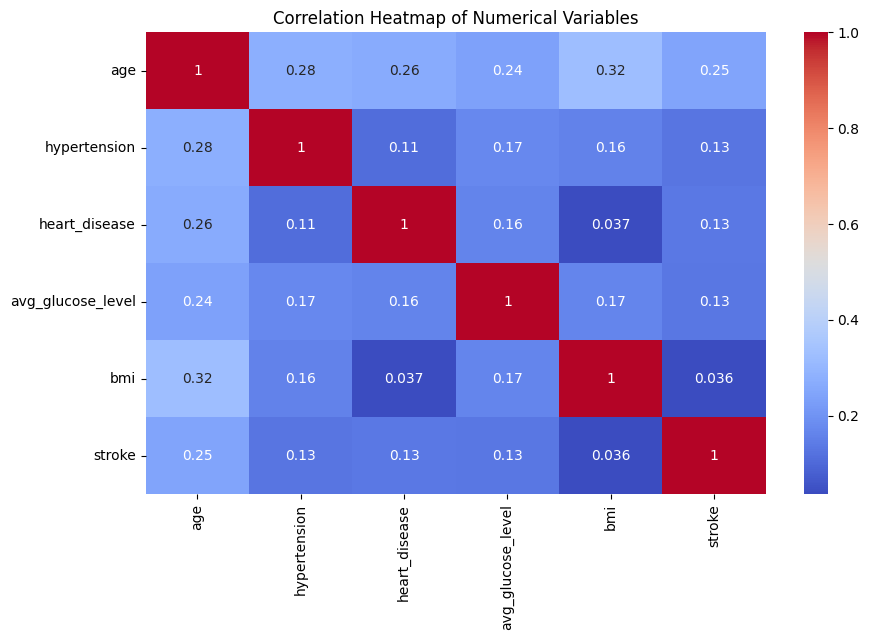

In [32]:
## Visualize Correlation Heatmap
# Create chart area.

plt.figure(figsize=(10,6))

# Generate heatmap.
#
# annot=True displays correlation values.
#
# cmap="coolwarm" provides color variation.
#
# Positive correlations appear warmer.
# Negative correlations appear cooler.

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

# Add chart title.

plt.title("Correlation Heatmap of Numerical Variables")

# Display chart.

plt.show()

# **Interpretation**

The correlation heatmap shows the strength and direction of the linear relationships between the numerical variables in the dataset.

Among all variables, Age has the strongest positive correlation with Stroke (r = 0.25), indicating that stroke occurrence tends to increase with age. Although this is the highest correlation observed, the relationship is still moderate, suggesting that stroke is influenced by multiple factors rather than a single variable.

Hypertension, Heart Disease, and Average Glucose Level each show a positive correlation of approximately 0.13 with stroke. These relationships are weaker than age but suggest that higher prevalence of these conditions is associated with increased stroke occurrence.

BMI has the weakest correlation with stroke (r = 0.04), indicating a very weak linear relationship in this dataset.

The heatmap also shows positive correlations between Age and several other health-related variables, including hypertension, heart disease, BMI, and average glucose level. However, none of the correlations between predictor variables are particularly strong, suggesting limited multicollinearity among the numerical features.



# **Section 16: Top 5 EDA Findings**

# **EDA 13: Top 5 EDA Findings**

#  1. Age was the strongest factor associated with stroke


Stroke prevalence increased substantially across older age groups. Patients aged **66 years and above** exhibited the highest stroke rates, highlighting age as the variable most strongly associated with stroke occurrence in this dataset.

---

### 2. Hypertension showed a strong association with stroke

Patients diagnosed with **hypertension** experienced considerably higher stroke prevalence than patients without hypertension.

The stroke rate among hypertensive patients was more than three times higher than that of non-hypertensive patients, indicating a strong association between hypertension and stroke occurrence.

---

### 3. Heart disease was associated with increased stroke occurrence

Patients with **heart disease** experienced a substantially higher stroke rate compared to those without heart disease.

The stroke rate among patients with heart disease was more than four times higher than that of patients without heart disease, making heart disease one of the most important factors associated with stroke in the dataset.

---

### 4. Higher average glucose levels were observed among stroke patients

The distribution of average glucose levels among stroke patients was shifted toward higher values compared to non-stroke patients.

This finding suggests that elevated blood glucose levels may be associated with increased stroke occurrence.

---

### 5. The dataset is highly imbalanced

Out of **5,110** patients, only **249** experienced a stroke.

This represents approximately **4.87%** of all observations, while **95.13%** of patients did not experience a stroke.

The class imbalance should be considered during the machine learning phase to ensure that predictive models accurately identify stroke cases.

---

### Overall EDA Conclusion

The exploratory analysis identified **age, hypertension, heart disease, and average glucose level** as the variables most strongly associated with stroke occurrence. While BMI, residence type, marital status, work type, and smoking status showed varying patterns across groups, their associations were less pronounced. These findings provide valuable insights for feature selection and subsequent stroke risk prediction modeling.
